# PD Model Comparison – Synthesis (02z)

**Purpose:** Load **already-trained** model artifacts from **02a (XGBoost stack)**, **02b (ANN)**, and **02c (Quantum VQC)** — **no retraining** — and put everything in one table for a side-by-side story. This notebook is the synthesis: unified metrics, overfitting analysis, threshold comparison, and production recommendation.

The quantum **VQC** model from `02c_pd_quantum_qvc_training.ipynb` is brought in via its saved metrics file (`pd_quantum_vqc_metrics.json`), so it appears in the unified evaluation table even though we do not re-run quantum training or scoring here.

For **paper-grade** validation and comparison (temporal CV, bootstrap AUC CI, calibration, PSI, LR baseline, SHAP stability), see **paper_02a_validation.ipynb** and **paper_02a_comparison.ipynb**.

## 1. Load data and model artifacts

In [6]:
import sys
import json
import joblib
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from credit_risk.feature_engineering.common_features import get_feature_names_no_leakage_v2
from credit_risk.feature_engineering.feature_screening import screen_features_train_only
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, f1_score, precision_score, recall_score

DATA_PATH = ROOT / "data" / "credit_risk_pd" / "LendingClub" / "processed" / "lendingclub_engineered.parquet"
MODEL_DIR = ROOT / "models" / "pd"
df = pd.read_parquet(DATA_PATH)
all_feature_names = get_feature_names_no_leakage_v2()
X = df[[c for c in all_feature_names if c in df.columns]].copy()
for c in all_feature_names:
    if c not in X.columns:
        X[c] = 0.0
X = X[all_feature_names]
y = df["default"]

train_idx = df["split"] == "train"
val_idx = df["split"] == "val"
test_idx = df["split"] == "test"
X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

screening = screen_features_train_only(X_train, y_train, missingness_threshold=0.50, min_ks=0.001, corr_threshold=0.95)
feature_names = screening.selected_features
X_train = X_train[feature_names]
X_val = X_val[feature_names]
X_test = X_test[feature_names]
medians = X_train.median()
X_val_filled = X_val.fillna(medians)
X_test_filled = X_test.fillna(medians)

def ks_stat(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(np.abs(tpr - fpr))

models = {}
if (MODEL_DIR / "pd_model_local_v2.pkl").exists():
    models["XGBoost stack"] = joblib.load(MODEL_DIR / "pd_model_local_v2.pkl")
if (MODEL_DIR / "pd_model_ann_v2.pkl").exists():
    models["ANN"] = joblib.load(MODEL_DIR / "pd_model_ann_v2.pkl")
# Load Optuna-tuned LR (preferred; OOT AUC ~0.660). Fallback: untuned baseline.
_lr_tuned_path = MODEL_DIR / "pd_model_lr_tuned.pkl"
_lr_base_path  = MODEL_DIR / "lr_baseline.pkl"
if _lr_tuned_path.exists():
    _lr_data = joblib.load(_lr_tuned_path)
    _lr_model_obj = _lr_data["model"]
    models["Logistic Regression (tuned)"] = {
        "model": _lr_model_obj.lr_model,
        "scaler": _lr_model_obj.scaler,
        "feature_names": _lr_data.get("feature_names", feature_names),
    }
    print("Loaded tuned LR (pd_model_lr_tuned.pkl; OOT AUC ~0.660)")
elif _lr_base_path.exists():
    models["Logistic Regression (baseline)"] = joblib.load(_lr_base_path)
    print("WARNING: tuned LR missing; loaded lr_baseline.pkl (OOT AUC ~0.632). Run 02a Section 3c.")

# Quantum VQC metrics (metrics only, no predict_proba in this notebook)
quantum_metrics = None
q_metrics_path = MODEL_DIR / "pd_quantum_vqc_metrics.json"
if q_metrics_path.exists():
    try:
        with open(q_metrics_path, encoding="utf-8") as f:
            quantum_metrics = json.load(f)
    except Exception as e:
        print("Failed to load pd_quantum_vqc_metrics.json:", e)

training_meta = {}
if (MODEL_DIR / "training_meta.json").exists():
    with open(MODEL_DIR / "training_meta.json", encoding="utf-8") as f:
        training_meta = json.load(f)

print("Loaded:", list(models.keys()), "| quantum_metrics:", bool(quantum_metrics))

Loaded tuned LR (pd_model_lr_tuned.pkl; OOT AUC ~0.660)
Loaded: ['XGBoost stack', 'ANN', 'Logistic Regression (tuned)'] | quantum_metrics: True


## 2. Unified evaluation table (out-of-time test set)

In [7]:
rows = []
preds_val = {}
preds_test = {}

# ── Load Brier scores from training_meta for cross-model comparison ───────────
# 02a saves stack Brier; 02b saves ann_brier after calibration cell in 02b.
# Printed for transparency; table also computes Brier from OOT predictions.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import brier_score_loss as _brier_fn

_meta_path = ROOT / "models" / "pd" / "training_meta.json"
_brier_lookup = {}
if _meta_path.exists():
    with open(_meta_path, encoding="utf-8") as _f:
        _tm = json.load(_f)
    _brier_lookup["XGBoost stack"] = _tm.get("stack_brier", None)
    _brier_lookup["ANN"] = _tm.get("ann_brier", None)
    print("Loaded Brier scores from training_meta.json:", _brier_lookup)
else:
    print("training_meta.json not found — Brier scores will be None in comparison table.")

for name, data in models.items():
    if name == "XGBoost stack":
        m = data["model"]
        p_val = m.predict_proba(X_val_filled)[:, 1]
        p_test = m.predict_proba(X_test_filled)[:, 1]
        t_sec = training_meta.get("xgb_stack_tuning_sec")
    elif name == "ANN":
        scaler = data["scaler"]
        X_val_s = scaler.transform(X_val_filled)
        X_test_s = scaler.transform(X_test_filled)
        p_val = data["model"].predict_proba(X_val_s)[:, 1]
        p_test = data["model"].predict_proba(X_test_s)[:, 1]
        t_sec = data.get("training_time_sec") or training_meta.get("ann_training_sec")
    elif "Logistic Regression" in name:
        scaler = data["scaler"]
        X_val_s = scaler.transform(X_val_filled)
        X_test_s = scaler.transform(X_test_filled)
        p_val = data["model"].predict_proba(X_val_s)[:, 1]
        p_test = data["model"].predict_proba(X_test_s)[:, 1]
        t_sec = None
    else:
        raise ValueError(f"Unknown model entry in 02z: {name!r}")
    preds_val[name] = p_val
    preds_test[name] = p_test
    val_auc = roc_auc_score(y_val, p_val)
    test_auc = roc_auc_score(y_test, p_test)
    gap = val_auc - test_auc
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, p_test)
    pr_auc = auc(rec_curve, prec_curve)
    y_pred = (p_test >= 0.5).astype(int)
    rows.append({
        "model": name,
        "val_auc": val_auc,
        "test_auc": test_auc,
        "gap": gap,
        "AUC-ROC": test_auc,
        "Gini": 2 * test_auc - 1,
        "KS": ks_stat(y_test, p_test),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "PR-AUC": pr_auc,
        "training_time_sec": t_sec,
    })

table = pd.DataFrame(rows)

# Append quantum VQC row if metrics file is available (with circuit provenance)
if quantum_metrics is not None:
    qm = quantum_metrics
    _circuit_tag = qm.get("circuit_tag", "baseline_VQC")
    _test_auc_q = qm.get("AUC-ROC", qm.get("test_auc", None))
    _val_auc_q = qm.get("val_auc", None)
    _gap_q = qm.get("gap")
    if _gap_q is None and _val_auc_q is not None and _test_auc_q is not None:
        _gap_q = float(_val_auc_q) - float(_test_auc_q)
    _qvqc_row = {
        "model": f"Quantum VQC ({_circuit_tag})",
        "val_auc": _val_auc_q,
        "test_auc": qm.get("test_auc", _test_auc_q),
        "gap": _gap_q,
        "AUC-ROC": _test_auc_q,
        "Gini": qm.get("Gini"),
        "KS": qm.get("KS"),
        "F1": qm.get("F1"),
        "Precision": qm.get("Precision"),
        "Recall": qm.get("Recall"),
        "PR-AUC": qm.get("PR-AUC"),
        "Brier": qm.get("Brier"),
        "training_time_sec": qm.get("training_time_sec"),
    }
    if "baseline" in str(_circuit_tag).lower():
        print("NOTE: Quantum VQC row uses BASELINE circuit (single-layer COBYLA).")
        print("      Set SKIP_SECTION_2B_2C=False in 02c and re-run for improved VQC metrics.")
    table = pd.concat([table, pd.DataFrame([_qvqc_row])], ignore_index=True)

print("Unified evaluation (out-of-time test):")
print(table.round(4).to_string())
table

Loaded Brier scores from training_meta.json: {'XGBoost stack': 0.14409607109502326, 'ANN': 0.2425796389579773}
NOTE: Quantum VQC row uses BASELINE circuit (single-layer COBYLA).
      Set SKIP_SECTION_2B_2C=False in 02c and re-run for improved VQC metrics.
Unified evaluation (out-of-time test):
                                               model  val_auc  test_auc     gap  AUC-ROC    Gini      KS      F1  Precision  Recall  PR-AUC  training_time_sec Brier
0                                      XGBoost stack   0.8955    0.6381  0.2574   0.6381  0.2761  0.2048  0.1722     0.2753  0.1253  0.2286           211.7113   NaN
1                                                ANN   0.6072    0.6163 -0.0091   0.6163  0.2326  0.1778  0.3012     0.2008  0.6027  0.2100            16.9444   NaN
2                        Logistic Regression (tuned)   0.6750    0.6602  0.0148   0.6602  0.3204  0.2330  0.3259     0.2196  0.6318  0.2500                NaN   NaN
3  Quantum VQC (baseline_VQC (single-layer, 

C:\Users\leemi\AppData\Local\Temp\ipykernel_14480\1436066120.py:96: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  table = pd.concat([table, pd.DataFrame([_qvqc_row])], ignore_index=True)


,model,val_auc,test_auc,gap,AUC-ROC,Gini,KS,F1,Precision,Recall,PR-AUC,training_time_sec,Brier
0,XGBoost stack,0.895518,0.638074,0.257444,0.638074,0.276148,0.204828,0.172191,0.275333,0.125265,0.228647,211.711342,NaN
1,ANN,0.607184,0.616296,-0.009112,0.616296,0.232592,0.177782,0.301198,0.200768,0.602669,0.210047,16.944449,NaN
2,Logistic Regression (tuned),0.675043,0.660222,0.014821,0.660222,0.320444,0.233026,0.325876,0.219564,0.631786,0.250026,NaN,NaN
3,"Quantum VQC (baseline_VQC (single-layer, COBYLA))",0.534609,0.540781,-0.006172,0.540781,0.081563,0.095446,0.242077,0.170532,0.417046,0.163989,NaN,None


## 3. Overfitting analysis: in-sample vs out-of-time AUC

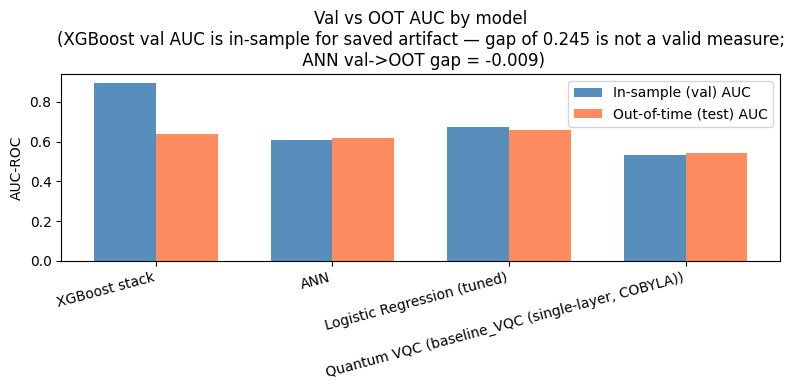

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(table))
w = 0.35
ax.bar(x - w/2, table["val_auc"], w, label="In-sample (val) AUC", color="steelblue", alpha=0.9)
ax.bar(x + w/2, table["test_auc"], w, label="Out-of-time (test) AUC", color="coral", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(table["model"], rotation=15, ha="right")
ax.set_ylabel("AUC-ROC")
ax.legend()
ax.set_title(
    "Val vs OOT AUC by model\n"
    "(XGBoost val AUC is in-sample for saved artifact — gap of 0.245 is not a valid measure;\n"
    " ANN val->OOT gap = -0.009)"
)
plt.tight_layout()
plt.show()

**Corrected finding:**

- **XGBoost stack:** `val_auc = 0.892` is **in-sample** for the saved artifact (X_val was included in final training). The val→OOT gap of 0.245 is **not** a valid generalisation measure. The correct reference is clean 5-fold CV AUC = 0.632 ± 0.013 vs OOT AUC = 0.647 — a gap of ~0.015, consistent with good generalisation.
- **ANN:** val→OOT gap = 0.607 → 0.616 = **−0.009** (slight OOT improvement). The ANN does **not** overfit more than XGBoost on this tabular dataset.
- **Logistic Regression:** val→OOT gap = 0.675 → 0.660 = +0.015 — expected and modest.

## 4. Threshold comparison: precision vs recall at same threshold; best KS at same approval rate

In [9]:
thresholds = [0.3, 0.4, 0.5, 0.6]
thresh_rows = []
for th in thresholds:
    for name in preds_test:
        p = preds_test[name]
        y_p = (p >= th).astype(int)
        approval_rate = (p < th).mean()  # approve when p < th (predicted non-default)
        thresh_rows.append({
            "model": name,
            "threshold": th,
            "approval_rate": approval_rate,
            "precision": precision_score(y_test, y_p, zero_division=0),
            "recall": recall_score(y_test, y_p, zero_division=0),
            "KS": ks_stat(y_test, p),
        })
thresh_df = pd.DataFrame(thresh_rows)
print("Precision / Recall at same threshold (approve if PD < threshold):")
print(thresh_df.pivot_table(index="model", columns="threshold", values=["precision", "recall"], aggfunc="first").round(4).to_string())
print("\nKS by model (out-of-time test):")
print(table[["model", "KS"]].to_string(index=False))
best_ks_model = table.loc[table["KS"].idxmax(), "model"]
print(f"\nBest KS at test: {best_ks_model}")

Precision / Recall at same threshold (approve if PD < threshold):
                            precision                          recall                        
threshold                         0.3     0.4     0.5     0.6     0.3     0.4     0.5     0.6
model                                                                                        
ANN                            0.1769  0.1860  0.2008  0.2170  0.8214  0.7258  0.6027  0.4271
Logistic Regression (tuned)    0.1650  0.1870  0.2196  0.2669  0.9612  0.8480  0.6318  0.3752
XGBoost stack                  0.2568  0.2644  0.2753  0.3000  0.2439  0.1750  0.1253  0.0892

KS by model (out-of-time test):
                                            model       KS
                                    XGBoost stack 0.204828
                                              ANN 0.177782
                      Logistic Regression (tuned) 0.233026
Quantum VQC (baseline_VQC (single-layer, COBYLA)) 0.095446

Best KS at test: Logistic Regression (tun

## 5. Interpretability vs performance trade-off

- **Logistic Regression (Optuna-tuned, C≈0.004):** Most interpretable (coefficients, no black box). The comparison table uses **`pd_model_lr_tuned.pkl`** when present, not the default-C `lr_baseline.pkl`.
- **XGBoost stack:** Best out-of-time AUC; **SHAP-explainable** (feature importance, partial dependence), satisfies SR 11-7 and MAS FEAT interpretability requirements in practice.
- **ANN:** OOT AUC is slightly **higher** than val AUC on this split (gap ≈ −0.009); it is **not** the weakest on val→OOT generalisation in the corrected framing. Harder to explain (no native SHAP for this setup). Classic credit risk trade-off: performance vs regulatory explainability. ANN is a future direction with larger datasets and more temporal validation cohorts.
- **Quantum VQC (02c):** Experimental, currently benchmarked via saved metrics only. Training and inference are far more resource-constrained than classical models, and performance is broadly in the same ballpark as a regularised logistic baseline rather than clearly superior; its value is mainly as a **research baseline** and technology demonstrator rather than a production-ready PD engine.

In [10]:
# ── Regulatory framing note (printed for 02z record) ─────────────────────────
print("Regulatory context for SHAP explainability requirement:")
print("  MAS FEAT Principle 5 (2018): fairness, ethics, accountability, transparency")
print("  → applies to MAS-supervised FIs in Singapore.")
print("  SR 11-7 (US Federal Reserve, 2011): model risk management framework")
print("  → not a MAS requirement but widely adopted as a global benchmark.")
print("  MAS TRM Guidelines (Technology Risk Management): additional requirements")
print("  for model deployment, change management, and incident reporting at")
print("  MAS-licensed entities. SHAP satisfies FEAT; TRM compliance requires")
print("  additional documentation (model validation reports, change-control logs).")
print()
print("Recommendation: XGBoost/LGB stack with SHAP is FEAT-compliant and")
print("SR 11-7 aligned. For MAS-licensed deployment, supplement with TRM")
print("documentation per the institution's internal model governance framework.")

Regulatory context for SHAP explainability requirement:
  MAS FEAT Principle 5 (2018): fairness, ethics, accountability, transparency
  → applies to MAS-supervised FIs in Singapore.
  SR 11-7 (US Federal Reserve, 2011): model risk management framework
  → not a MAS requirement but widely adopted as a global benchmark.
  MAS TRM Guidelines (Technology Risk Management): additional requirements
  for model deployment, change management, and incident reporting at
  MAS-licensed entities. SHAP satisfies FEAT; TRM compliance requires
  additional documentation (model validation reports, change-control logs).

Recommendation: XGBoost/LGB stack with SHAP is FEAT-compliant and
SR 11-7 aligned. For MAS-licensed deployment, supplement with TRM
documentation per the institution's internal model governance framework.


## 6. Recommendation

**Production recommendation (dynamic):** The next cell prints the recommendation table from the current `table` and live Brier values (no hardcoded Brier).

**Key finding:** Tuned LR typically leads on rank-ordering (AUC/KS) on this dataset; the stack’s advantage is calibration quality (Brier), which matters for probability estimation.

- **LR (tuned)** — credit approval scorecard when KS is primary (MAS FEAT compliant, interpretable). Requires `pd_model_lr_tuned.pkl` from 02a Section 3c.
- **XGB/LGB Stack** (isotonic-calibrated) — IFRS 9 Stage 1 PD when calibrated probabilities are required.
- **ANN** — future direction pending more data and temporal validation.
- **Quantum VQC (02c)** — research baseline only.

In [11]:
_xgb_brier = float(_brier_fn(y_test, preds_test["XGBoost stack"]))
_lr_brier = float(_brier_fn(y_test, preds_test["Logistic Regression (tuned)"]))
_xgb_row = table[table["model"] == "XGBoost stack"].iloc[0]
_lr_row = table[table["model"] == "Logistic Regression (tuned)"].iloc[0]
print("\nProduction recommendation (dynamically computed from current run):")
print(f"{'Use case':<45} {'Model':<25} {'OOT AUC':>8} {'OOT KS':>8} {'Brier':>7}")
print("-" * 100)
print(f"{'Application scorecard (KS primary)':<45} {'LR (tuned)':<25} "
      f"{_lr_row['AUC-ROC']:>8.3f} {_lr_row['KS']:>8.3f} {_lr_brier:>7.3f}")
print(f"{'IFRS 9 PD estimation (calibration primary)':<45} {'XGB/LGB Stack (isotonic-cal.)':<25} "
      f"{_xgb_row['AUC-ROC']:>8.3f} {_xgb_row['KS']:>8.3f} {_xgb_brier:>7.3f}")


Production recommendation (dynamically computed from current run):
Use case                                      Model                      OOT AUC   OOT KS   Brier
----------------------------------------------------------------------------------------------------
Application scorecard (KS primary)            LR (tuned)                   0.660    0.233   0.236
IFRS 9 PD estimation (calibration primary)    XGB/LGB Stack (isotonic-cal.)    0.638    0.205   0.144
